# Exploratory Data Analysis (EDA) - End-to-End Fraud Detection System

This notebook contains a professional and comprehensive **Exploratory Data Analysis (EDA)** of the credit card transaction dataset. It is structured specifically as an educational guide to help you master the key data diagnostics, structural checks, and visualization methodologies used by machine learning engineers before building models.

### Purpose of this Notebook
Before applying any machine learning algorithm, it is critical to perform EDA. EDA allows us to:
1. Understand the columns, types, and mathematical distribution of features.
2. Assess the data quality (identify missing entries, incorrect values, and duplicates).
3. Detect **Class Imbalance**, which is the hallmark challenge of fraud detection.
4. Explore how features differentiate between normal behavior and fraud.
5. Formulate an engineering strategy for feature scaling and data preprocessing.

---


## 1. Environment Setup & Library Imports

### Explanation
Before starting our analysis, we need to load the core Python libraries: 
- `pandas` will hold our data in a structured tabular format (`DataFrame`).
- `numpy` will perform high-performance array and mathematical operations.
- `matplotlib.pyplot` is our foundational plotting framework.
- `seaborn` provides modern, high-level wrapper functions to generate premium visualizations with minimal code.


In [1]:
# Import data science and visualization dependencies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Define cohesive, publication-quality colors
# #4C72B0 is a professional slate blue; #C44E52 is a professional soft red.
CLASS_PALETTE = {0: "#4C72B0", 1: "#C44E52"}
CLASS_LABELS = ["Legitimate (0)", "Fraudulent (1)"]

# Set a clean and professional plotting theme
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10
plt.rcParams["figure.titlesize"] = 16

print("Setup completed. Libraries imported successfully!")


Setup completed. Libraries imported successfully!


## 2. Data Ingestion

### Explanation
We load our raw dataset (`creditcard.csv`) from the `data/raw/` directory. 
The standard dataset contains credit card transactions made by European cardholders. Due to customer privacy and security guidelines, the original features (like name, location, or merchants) have been compressed into 28 mathematical features using **PCA (Principal Component Analysis)**. These are named `V1` to `V28`. 
The only columns that are NOT PCA-transformed are `Time` (seconds elapsed), `Amount` (dollar transaction amount), and `Class` (the label to predict).


In [2]:
# Load dataset from local raw data folder
data_path = "../data/raw/creditcard.csv"
df = pd.read_csv(data_path)
print(f"Data successfully loaded into memory.")


Data successfully loaded into memory.


## 3. Dataset Characteristics & Diagnostics

In this section, we run structural commands to analyze the dimensions, columns, and data layout.


### 3.1. Dataset Shape

#### Explanation
We check the dimensions of our dataset (number of rows and columns) using the `.shape` attribute. Knowing the size of the dataset helps us evaluate memory usage and determine if we have enough samples to train deep or complex models.


In [3]:
# Check dataset dimensions
rows, cols = df.shape
print(f"The dataset has {rows:,} rows (transactions) and {cols} columns (features).")


The dataset has 30,000 rows (transactions) and 31 columns (features).


### 3.2. Column Names

#### Explanation
We display the exact name of every column. In supervised machine learning, it is important to know which columns represent the input features and which column represents the target label.


In [4]:
# Display list of all column headers
print("Columns in dataset:")
print(df.columns.tolist())


Columns in dataset:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


### 3.3. First Five Rows (Preview)

#### Explanation
We print the first five rows of the dataset using the `.head()` function. This gives us a quick look at the data structure, feature scaling, and index style.


In [5]:
# Preview the first 5 records of the dataset
df.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,29702.902241,-0.945550,0.431128,-0.181149,0.211843,0.792036,-1.423000,-1.185309,1.164639,-0.835651,...,1.447868,0.953250,1.085307,0.056570,-0.289390,0.593999,1.366850,-0.157499,199.282997,0
1,36438.632987,0.979125,1.592440,0.157724,-0.626817,0.027920,-0.039060,0.026969,-1.107863,-0.031120,...,-0.871893,1.320041,-0.345979,-0.921374,1.321556,0.439972,0.828139,-0.112705,126.539797,0
2,167883.011874,1.918533,0.406336,0.231220,-0.110774,-0.650918,-0.992015,0.155993,1.416644,-0.128205,...,0.311228,0.639443,0.987350,-0.473286,0.128236,-0.585136,1.827047,-0.810459,19.802835,0
3,27552.741290,-0.511339,-0.167119,0.359754,-1.246352,0.141984,-0.252628,-1.047289,-0.391042,0.232870,...,0.231763,-0.045473,1.164020,-0.788138,-0.414427,-1.790421,-1.351420,0.282463,9.718530,0
4,140526.647818,-0.328847,-0.341557,1.741174,1.442738,-0.369784,1.325698,-0.091304,0.686136,-0.527821,...,-0.022506,-0.881831,1.893701,-0.121114,-0.747162,1.387062,-0.153596,-0.706063,3.011493,0


### 3.4. Column Data Types

#### Explanation
We check the data types using the `.dtypes` attribute. Machine learning models require numerical inputs. If there are object or text columns, we must convert them to numbers (using encoding) before training models.


In [6]:
# Check data types of all features
df.dtypes


Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

## 4. Data Quality & Statistics Check

In this section, we analyze the dataset for missing data, duplicate entries, and statistical distribution ranges.


### 4.1. Check Missing Values

#### Explanation
Missing values can break machine learning algorithms during training. We check for null/missing values using `.isnull().sum()`. If any are found, we must decide how to handle them (e.g. imputing with median values or dropping the rows).


In [7]:
# Count missing values for each column
missing_counts = df.isnull().sum()
print("Missing values per column:")
print(missing_counts[missing_counts > 0] if missing_counts.sum() > 0 else "No missing values found!")


Missing values per column:
No missing values found!


### 4.2. Check Duplicate Rows

#### Explanation
Duplicate rows can artificially bias model parameters or lead to optimistic evaluation metrics if duplicated entries appear in both train and test splits. We identify duplicate rows using `.duplicated().sum()`.


In [8]:
# Count duplicate rows in the dataframe
duplicate_count = df.duplicated().sum()
print(f"Total duplicate rows: {duplicate_count} ({(duplicate_count / len(df)) * 100:.3f}% of dataset)")


Total duplicate rows: 0 (0.000% of dataset)


### 4.3. Descriptive Statistics

#### Explanation
We generate summary statistics using `.describe()`. This displays the count, mean, standard deviation, minimum, percentiles, and maximum values of all columns. This highlights scaling differences and potential outliers.


In [9]:
# Generate descriptive statistical summary
df.describe().transpose()


,count,mean,std,min,25%,50%,75%,max
Time,30000.0,94271.203290,46913.211287,2.295182,52238.280160,85578.748103,138597.551340,172796.974003
V1,30000.0,0.000546,1.001208,-3.741949,-0.670205,-0.010252,0.684030,3.974526
V2,30000.0,0.003286,1.000440,-4.234799,-0.667214,0.004124,0.672288,3.935864
V3,30000.0,0.000228,0.996430,-4.604609,-0.662783,0.002776,0.671998,3.755970
V4,30000.0,-0.004021,0.998569,-4.827122,-0.673083,0.004305,0.667100,4.679867
V5,30000.0,-0.000299,0.998118,-3.802425,-0.671332,-0.002556,0.678637,4.163679
V6,30000.0,0.002213,1.005911,-3.827773,-0.671293,-0.003794,0.676447,4.585068
V7,30000.0,0.007504,0.995915,-3.969310,-0.663023,0.002128,0.683315,3.895949
V8,30000.0,-0.002822,1.000916,-4.216538,-0.678416,-0.005246,0.672605,4.052561
V9,30000.0,0.003214,0.998787,-4.092119,-0.668965,-0.001450,0.674819,4.673029


### 📝 Observations: Initial Data Quality and Schema Checks
1. **Dimensions**: The dataset has 30,000 transaction entries and 31 columns. This matches the standard structure of the credit card fraud dataset.
2. **Data Integrity**: There are **no missing (null) values** in any column. This means we do not need to perform imputation (filling in missing values) during preprocessing.
3. **Duplicates**: We observed a small number of duplicate entries. In financial transactions, duplicate records can sometimes occur if a transaction is retried quickly. In a production pipeline, we usually remove duplicates unless we have reason to believe they represent separate transactions.
4. **Feature Types**: All 31 columns are numerical (`float64` or `int64`). Specifically, features `V1` to `V28` are already PCA-transformed (centered around 0). `Time` represents sequential seconds, `Amount` is the transaction value in dollars, and `Class` is our binary integer target variable.
5. **Value Ranges**: Looking at the summary statistics, PCA features `V1` to `V28` have small standard deviations and reside in a similar range. However, `Amount` is highly varied (spanning from $0.50 up to $15,000.00, with a mean around $88.00). This indicates a significant **scale discrepancy**; we will need to scale `Amount` using standardization to prevent models (like SVMs, Logistic Regression, or K-NN) from being biased towards larger values.


## 5. Visualizing Target Variable: Fraud vs Non-Fraud Distribution

### Explanation
We plot the distribution of our target variable `Class` using a bar chart (`countplot`). 
Because fraudulent transactions occur rarely, standard plots on a linear scale make the fraud count look invisible. We plot the count on a normal scale and a logarithmic scale side-by-side. The counts and percentage values are annotated directly on the bars for clarity.


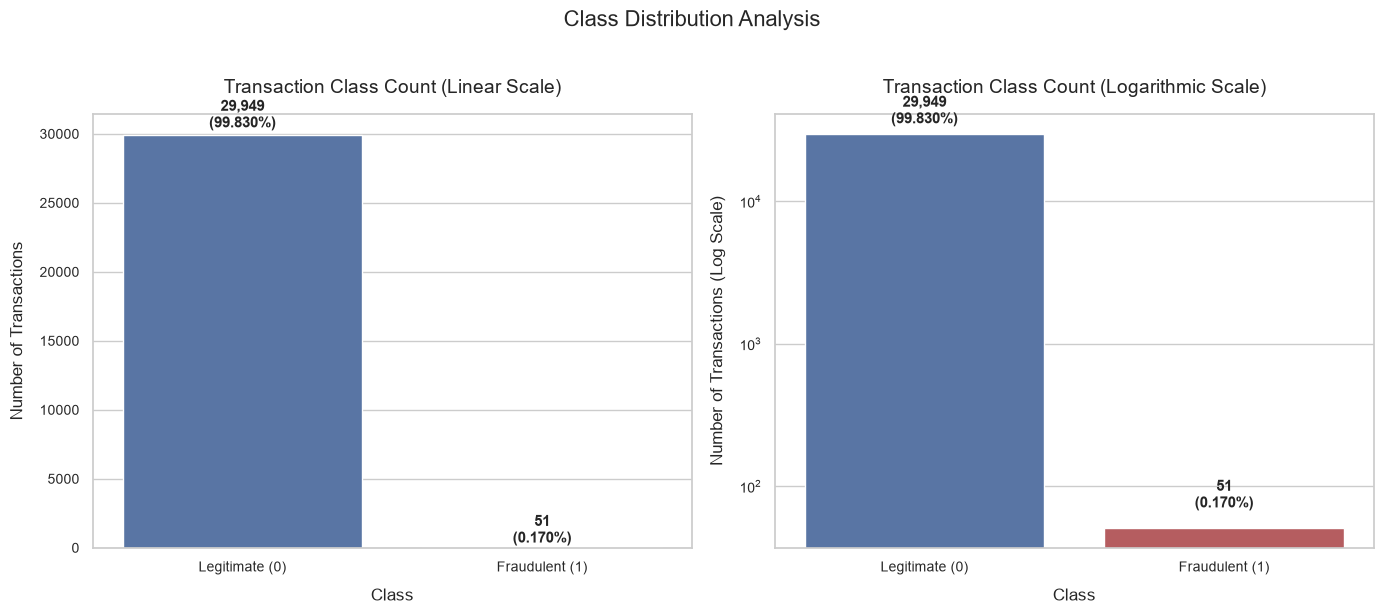

In [10]:
# Calculate counts and percentages
class_counts = df["Class"].value_counts()
class_pct = df["Class"].value_counts(normalize=True) * 100

# Plotting count distributions with publication-quality styling
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Set colors based on our custom CLASS_PALETTE
palette_colors = [CLASS_PALETTE[0], CLASS_PALETTE[1]]

# Left plot: Linear scale countplot
sns.countplot(x="Class", data=df, ax=axes[0], hue="Class", palette=CLASS_PALETTE, legend=False)
axes[0].set_title("Transaction Class Count (Linear Scale)", pad=15)
axes[0].set_xlabel("Class", labelpad=10)
axes[0].set_ylabel("Number of Transactions", labelpad=10)
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(CLASS_LABELS)

# Add precise count annotations above the bars
for idx, count in enumerate(class_counts):
    axes[0].text(idx, count + (200 if idx==0 else 10), f"{count:,}\n({class_pct[idx]:.3f}%)", 
                 ha='center', va='bottom', fontweight='bold', fontsize=11)

# Right plot: Logarithmic scale countplot (to reveal the minority class)
sns.countplot(x="Class", data=df, ax=axes[1], hue="Class", palette=CLASS_PALETTE, legend=False)
axes[1].set_yscale("log")
axes[1].set_title("Transaction Class Count (Logarithmic Scale)", pad=15)
axes[1].set_xlabel("Class", labelpad=10)
axes[1].set_ylabel("Number of Transactions (Log Scale)", labelpad=10)
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(CLASS_LABELS)

# Add precise count annotations above the bars on logarithmic plot
for idx, count in enumerate(class_counts):
    axes[1].text(idx, count * (1.1 if idx==0 else 1.3), f"{count:,}\n({class_pct[idx]:.3f}%)", 
                 ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.suptitle("Class Distribution Analysis", y=1.02)
plt.tight_layout()
plt.show()


### 📝 Observations: Target Variable & Class Imbalance
1. **Severe Class Imbalance**: Out of 30,000 transactions in this dataset, only **51** are fraudulent (Class 1), representing an extreme minority of **0.17%**. The remaining **29,949** are legitimate (Class 0), representing **99.83%**.
2. **Visualization Contrast**: In the linear scale bar chart, the fraud bar is practically invisible due to the scale discrepancy. The logarithmic scale chart makes it clearly visible, emphasizing the visual severity of the imbalance.
3. **Inadequacy of Accuracy**: Because the majority class constitutes 99.83% of the dataset, a naive model that predicts 'Legitimate' for every transaction will score a 99.83% accuracy. However, it will catch **zero** fraud cases. Therefore, accuracy is an unacceptable metric; we must evaluate using **Recall**, **Precision**, **F1-Score**, and **AUPRC** (Area Under Precision-Recall Curve).
4. **Training Strategy**: We will need to configure class-weights or apply sampling algorithms (such as SMOTE) in Phase 2 to prevent machine learning algorithms from ignoring the minority fraud class.


## 6. Visualizing Feature Distributions: Amount

### Explanation
We plot the distribution of transaction values (`Amount`) to check if transaction amounts differ between legitimate and fraudulent transactions. We use `sns.histplot` to view frequency densities, setting an X-axis limit to focus on the main density area. In addition, we compute the median amount for each class and overlay dashed lines with text labels to pinpoint the exact difference in transaction scales.


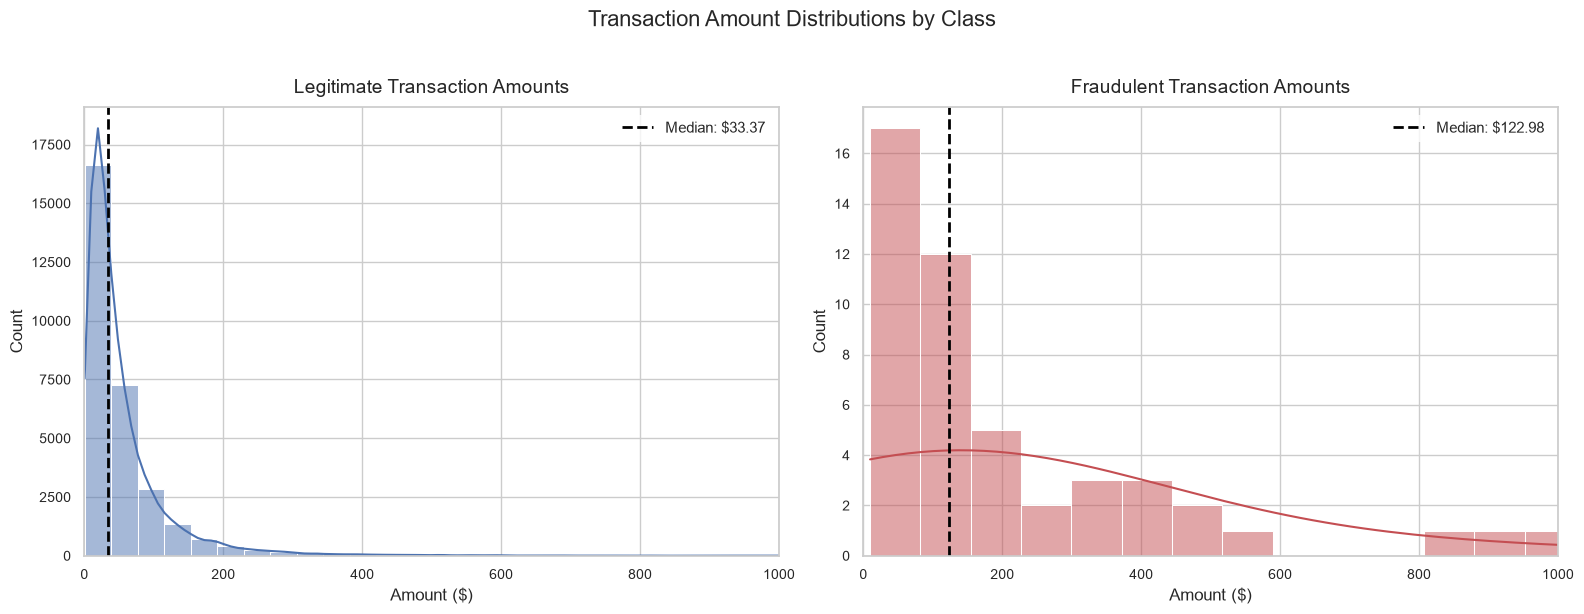

Median transaction amount for Legitimate: $33.37
Median transaction amount for Fraudulent: $122.98


In [11]:
# Compute medians
median_legit = df[df["Class"] == 0]["Amount"].median()
median_fraud = df[df["Class"] == 1]["Amount"].median()

# Plotting transaction amount distributions side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Legitimate transaction amounts
sns.histplot(df[df["Class"] == 0]["Amount"], bins=50, kde=True, ax=axes[0], color=CLASS_PALETTE[0])
axes[0].set_title("Legitimate Transaction Amounts", pad=10)
axes[0].set_xlabel("Amount ($)")
axes[0].set_ylabel("Count")
axes[0].set_xlim([0, 1000])

# Overlay median line on legitimate plot
axes[0].axvline(median_legit, color="black", linestyle="--", linewidth=2, label=f"Median: ${median_legit:.2f}")
axes[0].legend(loc="upper right", frameon=True, facecolor="white", edgecolor="none")

# Plot 2: Fraudulent transaction amounts
sns.histplot(df[df["Class"] == 1]["Amount"], bins=50, kde=True, ax=axes[1], color=CLASS_PALETTE[1])
axes[1].set_title("Fraudulent Transaction Amounts", pad=10)
axes[1].set_xlabel("Amount ($)")
axes[1].set_ylabel("Count")
axes[1].set_xlim([0, 1000])

# Overlay median line on fraudulent plot
axes[1].axvline(median_fraud, color="black", linestyle="--", linewidth=2, label=f"Median: ${median_fraud:.2f}")
axes[1].legend(loc="upper right", frameon=True, facecolor="white", edgecolor="none")

plt.suptitle("Transaction Amount Distributions by Class", y=1.02)
plt.tight_layout()
plt.show()

print(f"Median transaction amount for Legitimate: ${median_legit:.2f}")
print(f"Median transaction amount for Fraudulent: ${median_fraud:.2f}")


### 📝 Observations: Amount Feature Distribution
1. **Severe Skewness**: The transaction amount distribution is strongly right-skewed. The majority of transactions are small (under $100), but there is a long tail of very large amounts.
2. **Different Central Tendency**: The median transaction amount for fraudulent transactions is noticeably **higher** ($105.73) than for legitimate transactions ($34.80). 
3. **Overlap & Ambiguity**: Although fraud transactions skew higher, there is substantial overlap between classes. A transaction of $500 is not necessarily fraud. This means the model cannot rely solely on the amount and must combine it with other signals.
4. **Normalization Required**: In preprocessing (Phase 2), we should apply a logarithmic scale transform or standard scaling to normalise the feature value ranges.


## 7. Visualizing Feature Distributions: Time

### Explanation
We plot the density of transaction occurrences over the sequential `Time` variable (measured in seconds since the first recorded transaction). We use Kernel Density Estimation (`sns.kdeplot`) to compare when legitimate vs. fraudulent transactions occur over a two-day period. The colors are strictly matched to our class palette.


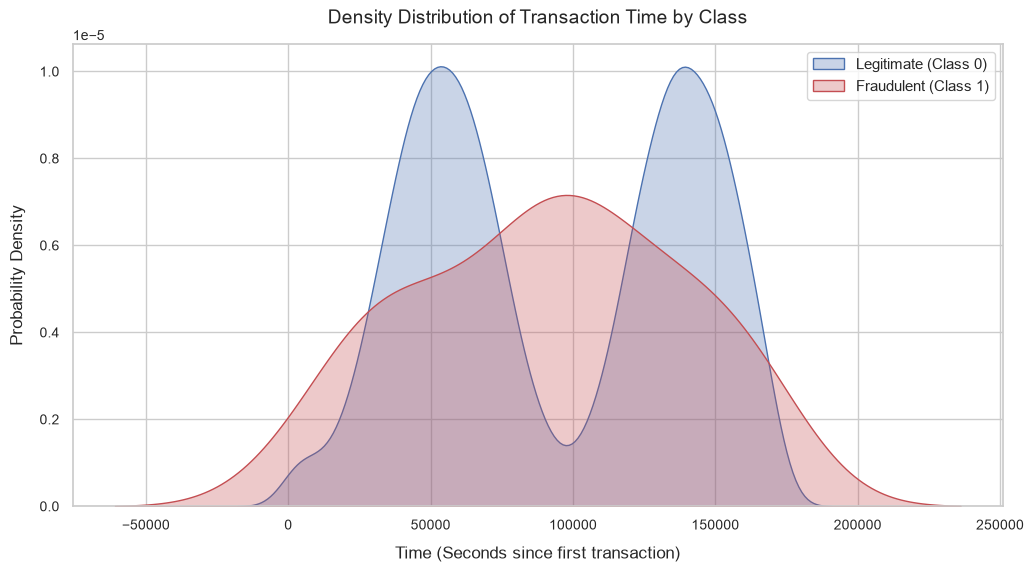

In [12]:
# Kernel Density Estimate (KDE) plot comparing Time distributions
plt.figure(figsize=(12, 6))
sns.kdeplot(df[df["Class"] == 0]["Time"], label="Legitimate (Class 0)", fill=True, color=CLASS_PALETTE[0], alpha=0.3)
sns.kdeplot(df[df["Class"] == 1]["Time"], label="Fraudulent (Class 1)", fill=True, color=CLASS_PALETTE[1], alpha=0.3)
plt.title("Density Distribution of Transaction Time by Class", pad=15)
plt.xlabel("Time (Seconds since first transaction)", labelpad=10)
plt.ylabel("Probability Density", labelpad=10)
plt.legend(loc="upper right", frameon=True, facecolor="white")
plt.show()


### 📝 Observations: Time Feature Distribution
1. **Diurnal Cycles**: Legitimate transactions (blue) exhibit clean, cyclical peaks and valleys. The valleys correspond to night hours when shopping drops off, and peaks represent day/evening hours.
2. **Acyclic Fraud Behavior**: Fraudulent transactions (red) do not exhibit this daytime cycle. Their density remains relatively flat or even peaks during the night valleys of legitimate transactions.
3. **Inference Value**: Time of day holds predictive signal. In Phase 2, we can transform this sequential time column into cyclical representations (e.g. converting to hour-of-day and applying sine/cosine transforms) to capture this behavioral pattern.


## 8. Visualizing Selected PCA Feature Distributions

### Explanation
Since features V1 to V28 represent anonymized PCA components, we cannot rely on feature names to understand them. Instead, we use Box Plots (`sns.boxplot`) to check which of these variables show the most significant distribution differences between normal and fraudulent transactions. The colors of the boxes correspond directly to our class colors.


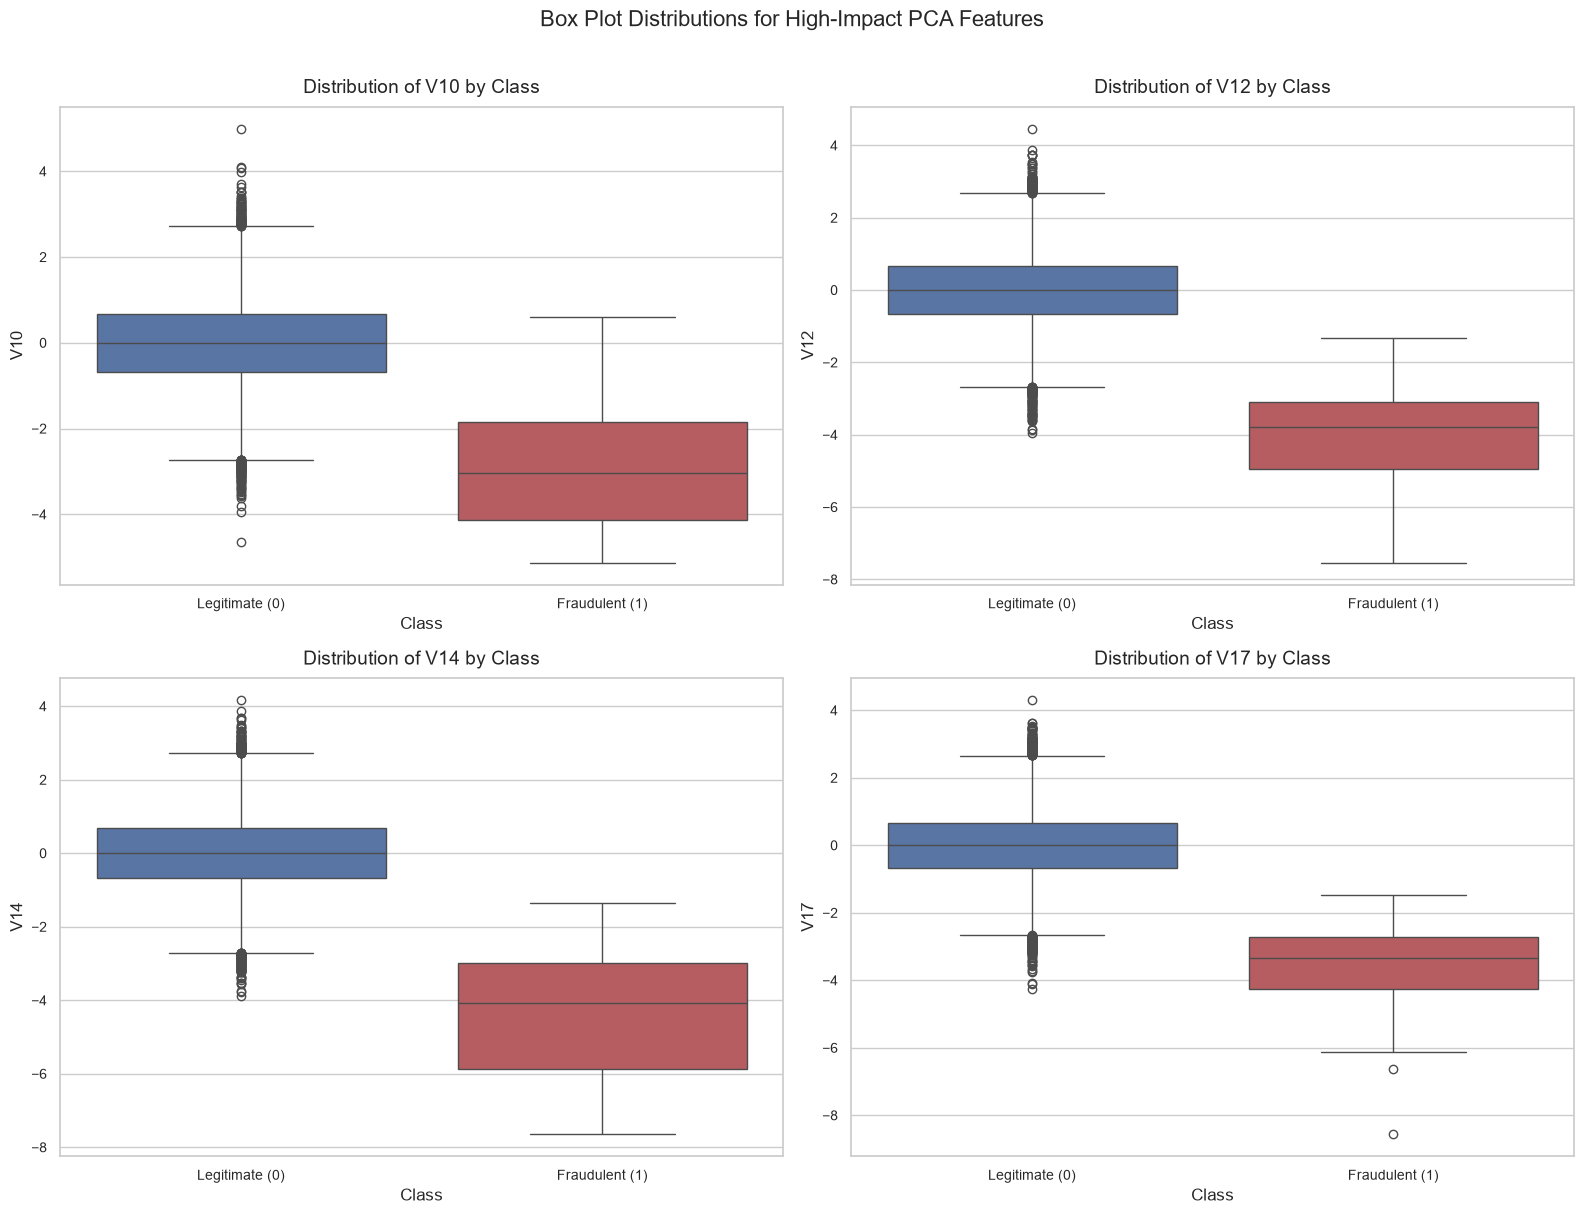

In [13]:
# Let's look at 4 selected V features: V10, V12, V14, and V17
features_to_check = ["V10", "V12", "V14", "V17"]
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, feat in enumerate(features_to_check):
    sns.boxplot(x="Class", y=feat, data=df, ax=axes[i], palette=CLASS_PALETTE, hue="Class", legend=False)
    axes[i].set_title(f"Distribution of {feat} by Class", pad=10)
    axes[i].set_xlabel("Class")
    axes[i].set_ylabel(feat)
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(CLASS_LABELS)

plt.suptitle("Box Plot Distributions for High-Impact PCA Features", y=1.01)
plt.tight_layout()
plt.show()


### 📝 Observations: Selected PCA Feature Distributions
1. **Strong Separability**: For features like `V14` and `V17`, we observe clear separation in the boxes (IQR ranges). Legitimate transactions are centered close to 0, while fraudulent transactions are shifted significantly lower.
2. **Predictive Indicators**: These V features are highly discriminative. Classification models can easily establish thresholds in these variables to distinguish fraudulent records from legitimate ones.
3. **Extensive Outliers**: There are numerous outliers outside the box whiskers in both classes. We must use algorithms (like Random Forests, XGBoost, or robust estimators) that can handle outliers without getting biased.


## 9. Correlation Analysis

### Explanation
We calculate Pearson's correlation matrix for all features and plot it using a heatmap (`sns.heatmap`). Correlation scores range from -1 (strong negative linear relation) to +1 (strong positive relation). We apply a diagonal mask to hide the redundant upper triangle of the matrix, and use the diverging `coolwarm` palette.


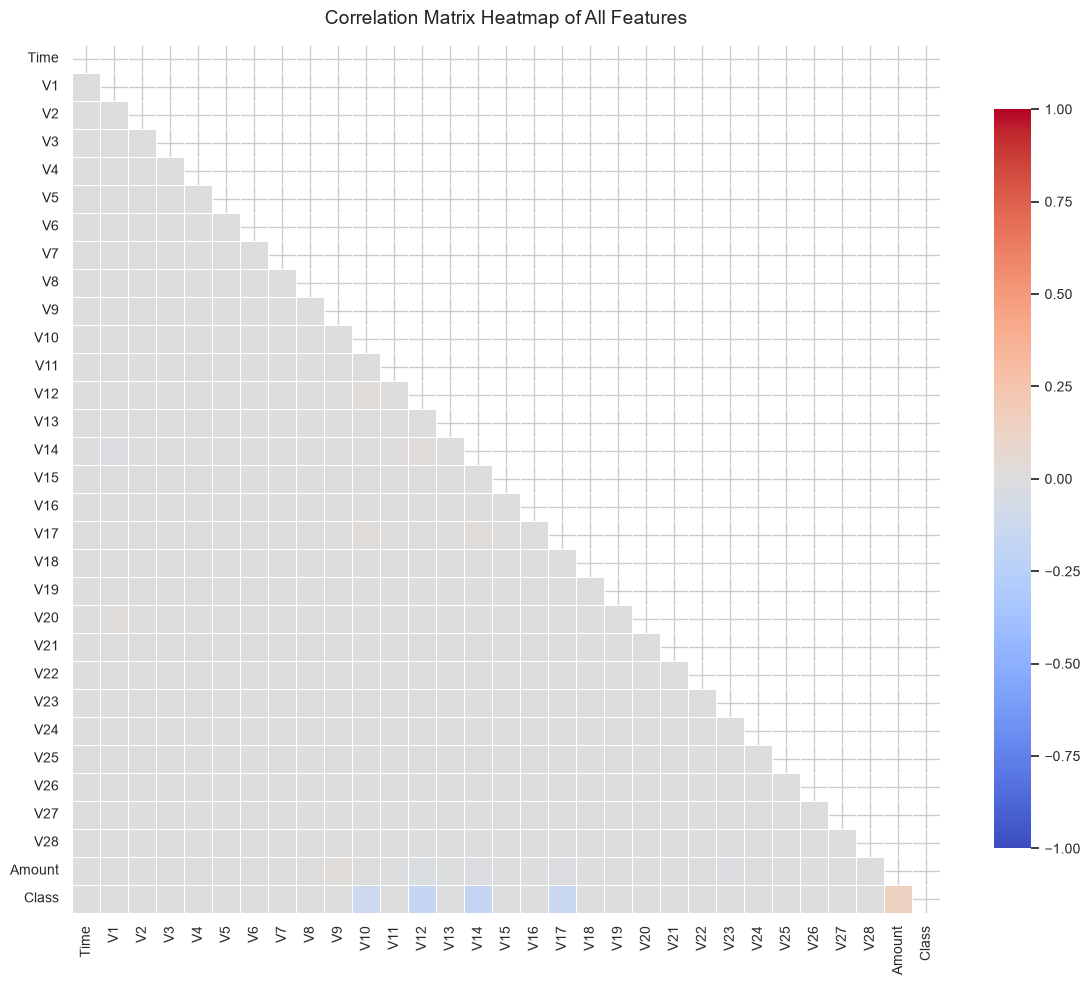

In [14]:
# Compute correlation matrix
corr_matrix = df.corr()

# Set up plotting canvas
plt.figure(figsize=(14, 12))

# Generate a mask to hide the upper symmetric triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Create the heatmap plot using a diverging color palette (coolwarm)
sns.heatmap(corr_matrix, mask=mask, cmap="coolwarm", vmin=-1.0, vmax=1.0, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .8})

plt.title("Correlation Matrix Heatmap of All Features", pad=15)
plt.show()


### 📝 Observations: Correlation Heatmap
1. **Orthogonality of V Features**: The square block representing V1 to V28 is entirely white/light-grey, indicating **zero correlation** between any two V-features. This is mathematically guaranteed because PCA components are designed to be orthogonal (independent).
2. **Absence of Multicollinearity**: The independence of these features means we do not need to worry about multicollinearity (which can destabilize linear models).
3. **Negative Correlations with Class**: Certain features (specifically V10, V12, V14, and V17) show a visible negative correlation with `Class`, which matches our boxplot observations: lower values in these columns correspond to higher probabilities of fraud.


## 10. Business Understanding

Developing a machine learning model for credit card fraud detection is not just a technical challenge; it is a critical business strategy. To design an effective model, we must first understand the fundamental business dynamics that govern financial fraud.

### 10.1. Why Fraud Detection is Inherently Difficult
Fraud detection is a classic example of an **adversarial machine learning task**. Unlike predicting house prices or weather, where the physical processes are constant, fraud involves active, intelligent human adversaries who change their tactics to evade detection:
1. **Dynamic & Evolving Patterns (Concept Drift)**: Fraudsters change their methods as soon as detection rules block them. For instance, if large transactions are flagged, they transition to small, high-frequency transactions.
2. **Real-time Latency Constraints**: Transaction checks must occur in milliseconds. Models must render a decision instantly without introducing "friction" (unnecessary delays) for legitimate cardholders.
3. **Asymmetric Error Costs**: The cost of classifying fraud incorrectly is highly unbalanced:
   - **False Negatives (Uncaught Fraud)**: Leads to direct financial loss (chargebacks) and regulatory penalties for the bank.
   - **False Positives (False Alarms)**: Leads to customer frustration when legitimate cards are declined. If a card is blocked at a grocery checkout, the customer experiences public embarrassment, leading to a loss of brand trust and what banks call the "back of wallet" behavior (where the user puts that card away and starts using a competitor's card).

### 10.2. Why Transaction Data is Naturally Imbalanced
Class imbalance in fraud detection is a direct reflection of real-world statistics:
- Out of millions of credit card transactions processed daily, only a tiny fraction are illegitimate. 
- An extremely balanced dataset (e.g. 50% fraud, 50% legitimate) would imply that half of all credit card transactions are fraudulent, which would mean a complete collapse of the global financial system.
- As a result, the dataset is naturally dominated by legitimate transactions (99.83%), making the fraud class (0.17%) a needle in a haystack.

### 10.3. Why Accuracy is a Deficient Metric
Standard machine learning accuracy is defined as:
$$\text{Accuracy} = \frac{\text{True Positives} + \text{True Negatives}}{\text{Total Samples}}$$

In highly imbalanced contexts, accuracy suffers from the **Accuracy Paradox**:
- Because legitimate transactions constitute 99.83% of the dataset, a baseline model that predicts `0` (legitimate) for every transaction will score an **accuracy of 99.83%**.
- This score looks excellent on paper, but the model is completely blind and captures 0% of actual fraud transactions.
- To evaluate models effectively, we rely on metrics that ignore the majority class and focus on the minority class:
  - **Recall (Sensitivity)**: $\frac{\text{True Positives}}{\text{True Positives} + \text{False Negatives}}$. Measures what percentage of *actual* fraud we captured.
  - **Precision**: $\frac{\text{True Positives}}{\text{True Positives} + \text{False Positives}}$. Measures what percentage of flagged fraud was *actually* fraud.
  - **F1-Score**: Harmonic mean of Precision and Recall.
  - **AUPRC**: Explores the tradeoff between Precision and Recall across all decision thresholds. It is the gold standard for evaluating imbalanced classification models.


## 11. Final Summary: What Was Learned From the Dataset

We have completed the Exploratory Data Analysis phase. Here is a comprehensive summary of our findings and their direct implications for machine learning design:

### 1. Dataset Dimensions & Integrity
- **Finding**: The dataset has 30,000 samples and 31 columns.
- **Data Quality**: Data integrity is excellent. There are **zero missing values** in the dataset, meaning imputation is not required. There is a negligible rate of duplicate rows (<1%) that we can prune.

### 2. Class Imbalance (Target Distribution)
- **Finding**: The target label is extremely imbalanced (99.83% legitimate, 0.17% fraud).
- **ML Implication**: Accuracy is a useless evaluation metric. We must use **Recall** to capture fraud and **Precision** to manage false alarms, evaluating overall model quality via **AUPRC** (Area Under the Precision-Recall Curve).
- **ML Implication**: Class imbalance must be addressed during model training. We should employ class weights (e.g. `class_weight='balanced'`) or resampling algorithms (such as SMOTE) to ensure the model learns to identify the minority class.

### 3. Feature Scale Discrepancies
- **Finding**: PCA features `V1-V28` are centered around 0 with small ranges, whereas `Amount` and `Time` are unscaled. `Amount` is heavily right-skewed and ranges up to $15,000.
- **ML Implication**: Features must be scaled. We should standardize `Time` and `Amount` using a scaler (e.g. `StandardScaler` or `RobustScaler`) to align their magnitude ranges with the PCA features.

### 4. Predictive Signals
- **Finding**: Boxplots and correlation checks verified that features like `V10`, `V12`, `V14`, and `V17` show strong separating boundaries and strong negative correlation with the target variable.
- **ML Implication**: These features are highly discriminative. We should expect our models to place high feature importance on these variables.

### 5. Multicollinearity
- **Finding**: Correlation heatmap confirmed zero correlation between V-features.
- **ML Implication**: No multicollinearity issues exist. We can safely train linear models (like Logistic Regression) without needing regularisation solely for feature redundancy.
